In [6]:
#pip install selenium

from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.webdriver.support.expected_conditions import *

import time
import json
import os
import csv

In [2]:
#pip install ddddocr

### Task 0: Login (Demo)

The first task is a demo showing how to use Selenium to log in to our CDS Shop website. Please replace the username and password with your own.

The steps are as follows:
1. Open the website (enter the URL).
2. Find the Login button.
3. Go to the login page (enter the login URL).
4. Locate the input fields.
5. Enter your username and password.
6. Click the Login button.

In [4]:
url = 'http://10.113.178.219:3000'

In [3]:
# selenium driver config
def open_driver(url):
    options = webdriver.ChromeOptions()
    options.add_experimental_option('excludeSwitches', ['enable-logging']) # for ignore warning and error
    options.add_argument("--Incognito")
    prefs = {
    "profile.default_content_setting_values.autofill": 2,
    "profile.password_manager_enabled": False,
    "credentials_enable_service": False,
    "autofill.profile_enabled": False,
    "autofill.address_enabled": False,
    "autofill.credit_card_enabled": False,
    }
    options.add_experimental_option("prefs", prefs)
    driver = webdriver.Chrome(options=options)
    driver.get(url)
    driver.implicitly_wait(5) # set a waiting time limit for the browser driver
    driver.maximize_window()
    return driver

In [ ]:
def login(driver):
    account = "mc5*****" # replace with your account
    password = "*****" # replace with your password

    '''
    The Login button is located in the top menu bar. It does not have a unique attribute, 
    so we can not target it directly. Instead, locate its parent menu, which has the 
    classes "ml-auto navbar-nav". Because it uses multiple classes, use a CSS selector 
    rather than class_name. 
    
    Alternatively, you can use the button XPath, but that will make the code less readable.
    '''
    nav_menu = driver.find_element(By.CSS_SELECTOR,'.ml-auto.navbar-nav')
    sign_in_page_button = nav_menu.find_elements(By.TAG_NAME, 'a')[1] # The login button is the second 'a' tag elemment from the menu
    print(sign_in_page_button.text) # To verify that the button is the one we want.
    sign_in_page_button.click()

    account_input = driver.find_element(By.ID,'email')
    account_input.send_keys(account)

    password_input = driver.find_element(By.ID,'password')
    password_input.send_keys(password)

    sign_in = driver.find_element(By.CSS_SELECTOR, ".btn.btn-primary") 
    sign_in.click()        

In [7]:
# t0
driver = open_driver(url)
login(driver)
# driver.close()

SIGN IN


### Task 1: Place an order

This task requires you to place an order to purchase 5 units of the last product available on the CDS shop.

1. Go to last page
2. Find the last product
3. Set the quantity as 5
4. Press add to Cart
5. Proceed to check out
6. Fill shipping information (type anything in the postal address...)
7. Continue until you reach the payment page

In [18]:
def go_to_last_page(driver):
    # write your code here
    login(driver)
    page_links = driver.find_elements(By.XPATH,"//ul[@class='pagination']/li/a")
    last_page_link = page_links[-1]
    last_page_link.click()
    return driver

In [8]:
def place_last_product(driver):
    # Find the last product
    
    last_product_link = driver.find_element(By.XPATH,'//*[@id="root"]/main/div/div[2]/div[2]/div/a')
    last_product_link.click()
    # Set the quantity as 5
    set_Qty = driver.find_element(By.XPATH,'//*[@id="root"]/main/div/div[1]/div[3]/div/div/div[3]/div/div[2]/select/option[5]')
    set_Qty.click()
    # Press add to Cart
    add_to_Cart_button = driver.find_element(By.XPATH,'//*[@id="root"]/main/div/div[1]/div[3]/div/div/div[4]/button')
    add_to_Cart_button.click()
    # Continue until you reach the payment page

    
    Address = 'University of Macao'
    City = 'Macao'
    Postal_Code = '999078'
    Country = 'China'
    time.sleep(5)
    #check out
    checkout_button = driver.find_element(By.XPATH,'//*[@id="root"]/main/div/div/div[2]/div/div/div[2]/button')
    checkout_button.click()
    
    Add_input = driver.find_element(By.XPATH,'//*[@id="address"]')
    Add_input.send_keys(Address)
    City_input = driver.find_element(By.XPATH,'//*[@id="city"]')
    City_input.send_keys(City)
    Postal_Code_input = driver.find_element(By.XPATH,'//*[@id="postalCode"]')
    Postal_Code_input.send_keys(Postal_Code)
    Country_input = driver.find_element(By.XPATH,'//*[@id="country"]')
    Country_input.send_keys(Country)

    continue_button = driver.find_element(By.XPATH,'//*[@id="root"]/main/div/div/div/div/form/button')
    continue_button.click()
    continue_button2 = driver.find_element(By.XPATH,'//*[@id="root"]/main/div/div/div/div/form/button')
    continue_button2.click()
    place_order_button = driver.find_element(By.XPATH,'//*[@id="root"]/main/div/div[2]/div[2]/div/div/div[7]/button')
    place_order_button.click()

   
    return 0


In [9]:
# t1
driver = open_driver(url) # enable it if the driver is closed
driver = go_to_last_page(driver)
place_last_product(driver)

SIGN IN


0

### Task 2: Fetch the products with specific price

This task requires you to retrieve all the products with a stock quantity of at least 20.

1. Iterate through all pages.
2. Open each product detail page in a new tab.
3. Locate the in stock quantity.
4. If quantity ≥ 20, store the product name.

In [20]:
def go_to_next_page(driver):
    # write your code here
    active_li = driver.find_element(By.CSS_SELECTOR, 'li.active.page-item.active')
    page_number_span = active_li.find_element(By.CSS_SELECTOR, 'span.page-link')  
    page_number = int(re.findall(r'\d+',page_number_span.text)[0])
    time.sleep(2)
    if page_number != 22:
        num = page_number + 1
        next_page = driver.find_element(By.CSS_SELECTOR, f'a.page-link[href*="/page/{num}"]')
        next_page.click()
        return driver
    else:
        return False
    # return False if there's no next page

In [11]:
def get_quantity(driver):
    quantity = 0
    # write your code
    select_element = driver.find_element(By.XPATH, '//*[@id="root"]/main/div/div[1]/div[3]/div/div/div[3]/div/div[2]/select')
    options = select_element.find_elements(By.TAG_NAME, 'option')
        
        
    quantities = []
    for option in options:
            # search
        content = f"{option.text} {option.get_attribute('value')}"
        numbers = re.findall(r'\d+', content)
        quantities.extend([int(num) for num in numbers])
        
    result = max(quantities) if quantities else 0
    #print(f"最终结果: {result}")
    return result

In [12]:
'''
If you navigate into a product by clicking directly and then go back, 
you will end up in a different driver session. This breaks the ability to click the next 
pages discovered in the original session. To avoid this, open product pages in a new browser
tab instead.
'''

def open_products_in_new_tab(driver):
    # write your code here 
    product_names = []
    card_bodys = driver.find_elements(By.XPATH,'//*[@id="root"]/main/div/div[2]/div') 
    for card_body in card_bodys:
        product_link = card_body.find_element(By.XPATH,'.//div/a') 
        product_name = card_body.find_element(By.XPATH,'.//div/a/div/strong').text # 
        #product_names.append(product_name)
        '''
            The following code is to open the product page in new tab
        '''
        if os.name == 'posix':
            # check Operation System, os.name =='posix' indicate the OS is Mac OS or linux
            product_link.send_keys(Keys.COMMAND, Keys.RETURN)
        else:
            product_link.send_keys(Keys.CONTROL, Keys.RETURN)
            
        WebDriverWait(driver, 5).until(EC.number_of_windows_to_be(2))
        windows = driver.window_handles
        # switch to handle the new window tab
        driver.switch_to.window(windows[-1])


        '''
            Now that you’re on the product page, please fetch the required information
        '''
        product=get_quantity(driver)
        if product >= 20:
            product_names.append(product_name)
        
        driver.close()
        driver.switch_to.window(windows[0])
    return product_names

In [13]:
# t2
driver = open_driver(url) # enable it if the driver is closed
product_list=[]
while True:
    driver = go_to_next_page(driver)
    if (not driver): break
    product_names = open_products_in_new_tab(driver)
    product_list.append(product_names)

print(product_list)

KeyboardInterrupt: 

### Task 3: Purchase the 10 most expensive products.
This task entails adding the 10 most expensive products to the cart in a **single order** and proceeding with the payment.

To proceed with the payment, you are required to pass a **captcha code test** using the ["ddddocr"](https://github.com/sml2h3/ddddocr) library.

1. Empty the carts
2. Get the names of the 10 most expensive products.
3. Add them into cart by searching products name.
4. Place the order when all the products are in the carts.
5. Proceed the payment.

In [ ]:
def empty_carts(driver):
    # write your code
    try:
        products = driver.find_elements(By.XPATH,'//*[@id="root"]/main/div/div/div[1]/div/div')
        for product in products:
            delete_button = product.find_element(By.XPATH,'.//div/div[5]/button')
            delete_button.click()
        go_fir_page = driver.find_element(By.XPATH,'//*[@id="root"]/header/nav/div/a')
        go_fir_page.click()
        return driver
    except Exception as e: 
        go_fir_page = driver.find_element(By.XPATH,'//*[@id="root"]/header/nav/div/a')
        go_fir_page.click()
        return driver

In [ ]:
import heapq


def get_top_10_indices(nums):
    
    indexed_nums = list(enumerate(nums))
    
    # top10
    top_10 = sorted(indexed_nums, key=lambda x: x[1], reverse=True)[:10]
    
    # index
    top_10_indices_sorted = sorted([index for index, _ in top_10])
    
    return top_10_indices_sorted

def get_elements_by_indices(list_to_search, indices):
      
    elements = []
    for i in indices:
        elements.append(list_to_search[i])
    return elements
    
def fetch_top10_names(driver):
    # write your code here
    names = []
    links = []
    products_name = []
    products_price = []

    while True:
        if (not driver): break
        card_bodys = driver.find_elements(By.XPATH,'//*[@id="root"]/main/div') 
        for card_body in card_bodys:
            product_price_elem = card_body.find_element(By.XPATH, './/div/div/h3')
            product_price_text = product_price_elem.text
            product_price = ''.join(filter(lambda x: x.isdigit() or x == '.', product_price_text))
            product_price = float(product_price) 
            product_name = card_body.find_element(By.XPATH,'.//div/a/div/strong').text 
            products_name.append(product_name)
            products_price.append(float(product_price))
        driver = go_to_next_page(driver)
    numbers = get_top_10_indices(products_price)
    names = get_elements_by_indices(products_name,numbers)

    
    return names

In [ ]:
def place_products_orders(driver,names):
    # write your code here
    go_to_fir_page = driver.find_element(By.XPATH,'//*[@id="root"]/header/nav/div/a')
    go_to_fir_page.click()
    i=0
    while True:
        if (not driver): break
        card_bodys = driver.find_elements(By.XPATH,'//*[@id="root"]/main/div/div[2]/div')
        for card_body in card_bodys:
            product_name = card_body.find_element(By.XPATH, './/div/a/div/strong').text.strip()
            if i <10:
                if names[i] == product_name:
                    product_link = card_body.find_element(By.XPATH,'.//div/a')
                    if os.name == 'posix':
                    # check Operation System, os.name =='posix' indicate the OS is Mac OS or linux
                        product_link.send_keys(Keys.COMMAND, Keys.RETURN)
                    else:
                        product_link.send_keys(Keys.CONTROL, Keys.RETURN)
            
                    WebDriverWait(driver, 5).until(EC.number_of_windows_to_be(2))
                    windows = driver.window_handles
                    # switch to handle the new window tab
                    driver.switch_to.window(windows[-1])
                    time.sleep(5)
                    add_button = driver.find_element(By.XPATH,'//*[@id="root"]/main/div/div[1]/div[3]/div/div/div[4]/button')
                    add_button.click()
                    time.sleep(2)
                    driver.close()
                    driver.switch_to.window(windows[0])
                    i = i + 1

        driver = go_to_next_page(driver)

    
    return 0

In [ ]:
pip install ddddocr --upgrade

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
import base64
from PIL import Image
import io
import ddddocr
# 添加兼容性定义（在导入 ddddocr 之前）
if not hasattr(Image, 'ANTIALIAS'):
    Image.ANTIALIAS = Image.Resampling.LANCZOS
def pay_for_order(driver):
    # write your code here
    go_to_cart = driver.find_element(By.XPATH,'//*[@id="basic-navbar-nav"]/div/a')
    go_to_cart.click()

    time.sleep(10)
    driver.refresh()
    time.sleep(2)
    driver.refresh()

    checkout_button = driver.find_element(By.XPATH,'//*[@id="root"]/main/div/div/div[2]/div/div/div[2]/button')
    checkout_button.click()
    
    Address = 1
    City = 1
    Postal_Code = 1
    Country = 1
    time.sleep(5)
    

    Address_input = driver.find_element(By.XPATH,'//*[@id="address"]')
    Address_input.send_keys(Address)
    City_input = driver.find_element(By.XPATH,'//*[@id="city"]')
    City_input.send_keys(City)
    Postal_Code_input = driver.find_element(By.XPATH,'//*[@id="postalCode"]')
    Postal_Code_input.send_keys(Postal_Code)
    Country_input = driver.find_element(By.XPATH,'//*[@id="country"]')
    Country_input.send_keys(Country)
    continue_button = driver.find_element(By.XPATH,'//*[@id="root"]/main/div/div/div/div/form/button')
    continue_button.click()
    continue_button2 = driver.find_element(By.XPATH,'//*[@id="root"]/main/div/div/div/div/form/button')
    continue_button2.click()
    place_order_button = driver.find_element(By.XPATH,'//*[@id="root"]/main/div/div[2]/div[2]/div/div/div[7]/button')
    place_order_button.click()
    time.sleep(5)
    
    # execute_script() to get Canvas's image
    canvas_base64 = driver.execute_script("return document.querySelector('canvas').toDataURL('image/png').split(',')[1];")

    # translate to Binary
    image_data = base64.b64decode(canvas_base64)

    # open
    image = Image.open(io.BytesIO(image_data))

    # use ddddocr
    ocr = ddddocr.DdddOcr()
    with io.BytesIO() as output:
        image.save(output, format="PNG")
        image_bytes = output.getvalue()
    result = ocr.classification(image_bytes)

    captcha_code = driver.find_element(By.XPATH,'//*[@id="user_captcha_input"]')
    captcha_code.send_keys(result)

    submit_button = driver.find_element(By.XPATH,'//*[@id="root"]/main/div/div/div[2]/div/div/div[6]/div/div/div/div[3]/div/button')
    submit_button.click()

    
    return 0

In [ ]:
#t3
driver = open_driver(url)
login(driver)
empty_carts(driver)
   
    
driver = go_to_next_page(driver)
time.sleep(2)
names = fetch_top10_names(driver)
print(names)
place_products_orders(driver,names)
pay_for_order(driver)
time.sleep(5)
    

    

SIGN IN
['Asia Roman emperor Art Anchor Handle', 'Dell Fashion Lite Small', 'Huawei Accessories Lite XXL', 'Huawei MateBook 14s', "L'Oreal Home Entertainment Exclusive Medium", "Levi's Computers Deluxe 10-Pack", 'Microsoft Home Entertainment Pro Bundle', 'Pear Style Wax Stamp Anchor Roman emperor', 'Sony Wearables Deluxe XXL', 'wonderful - Asia Roman emperor WorldWide']


---


### Task 4: Flash sale (bonus)

This task is time-sensitive, and only the earliest paid orders will secure the products. Timing is measured by payment completion, not order creation. During a randomly scheduled time slot (announced in class), select items will have their prices reduced. Your job is to identify these discounted products, place the orders, and complete payment immediately. Successful purchases—paid within the window will be marked as delivered, as shown in the example image. Further details will be provided in class.



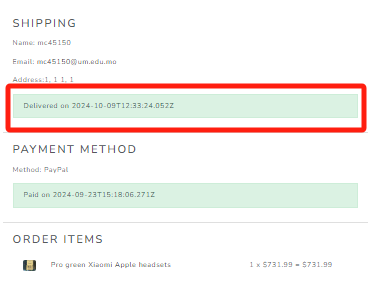

1. You are expected to crawl and store the names and prices of all products in advance.
2. There will be 4 rounds for the flash sale, with the quota decreasing as each round progresses.
3. Only an order with completed payment and each order containing only one product will be considered a valid order.
4. Submit your purchasing code in the following code block. 


In [9]:
def get_price(driver):
    
    products_name = []
    products_price = []

    while True :
            if (not driver): break
            # 获取当前页面所有商品
            card_bodys = driver.find_elements(By.XPATH, '//*[@id="root"]/main/div/div[2]/div')
            
            
            for card_body in card_bodys:
                
                product_name = card_body.find_element(By.XPATH, './/div/a/div/strong').text.strip()
                products_name.append(product_name)


                product_price_elem = card_body.find_element(By.XPATH, './/div/div/h3')
                product_price_text = product_price_elem.text
                product_price = ''.join(filter(lambda x: x.isdigit() or x == '.', product_price_text))
                product_price = float(product_price) 
                products_price.append(float(product_price))
                
            my_dict = dict(zip(products_name, products_price))
            driver = go_to_next_page(driver)
    

    
    return my_dict

In [ ]:
#get original price
driver = open_driver(url) # enable it if the driver is closed
all_products_price={}

all_products_price = get_price(driver)
    
    

print(all_products_price)


{'- 19th centery Flower Art Roman emperor': 66.99, '- Art Asia Roman emperor Used': 552.99, '- WorldWide Roman emperor Wax Stamp Vintage': 903.99, '128GB OPPO Watch Plus 5G Pro': 343.99, '19th centery Style Wax Stamp Used Butterfly': 521.99, '2021 Apple TV 4K 32GB': 570.99, '256GB 5G Redmi Note red 2nd Generation': 170.99, '256GB Pro 5G purple Internation Version': 5.99, '2nd Generation 64GB red OPPO Watch 3rd Generation': 245.99, '3rd Generation 2nd Generation red headsets Gold': 623.99, '3rd Generation 5G 64GB Plus accessories': 40.96, '3rd Generation Gold 128GB cell Phones_smartphones Apple': 493.99, '3rd Generation red OPPO Watch Redmi Note headsets': 59.99, '5G 3rd Generation 2nd Generation cell Phones_smartphones Internation Version': 723.99, '64GB 3rd Generation cell Phones smartphones Internation Version Plus': 174.99, 'Adidas Audio Lite Medium': 1404.71, 'Adidas Beauty Deluxe 10-Pack': 1984.24, 'AirTag': 29.99, 'Airpods Wireless Bluetooth Headphones': 89.99, 'Amazon Echo Dot 3

In [11]:
import csv
all_products_price={}
def save_dict_to_csv(data_dict, filename):
    """将字典保存为CSV文件"""
    if filename is None:
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        filename = f"products_data_{timestamp}.csv"
    elif not filename.endswith('.csv'):
        filename += '.csv'
    
    try:
        with open(filename, 'w', newline='', encoding='utf-8') as f:
            writer = csv.writer(f)
            # 写入表头
            writer.writerow(['商品名称', '价格'])
            # 写入数据
            for product_name, price in data_dict.items():
                writer.writerow([product_name, price])
        
        print(f"✅ 数据已保存到: {filename}")
        return filename
    except Exception as e:
        print(f"❌ 保存CSV文件失败: {e}")
        return None
save_dict_to_csv(all_products_price,'E:\producr_list')

✅ 数据已保存到: E:\producr_list.csv


<>:25: SyntaxWarning: invalid escape sequence '\p'
<>:25: SyntaxWarning: invalid escape sequence '\p'
C:\Users\13656\AppData\Local\Temp\ipykernel_27720\2084053136.py:25: SyntaxWarning: invalid escape sequence '\p'
  save_dict_to_csv(all_products_price,'E:\producr_list')


'E:\\producr_list.csv'

In [12]:
def find_different_values(dict1, dict2):
    """找到相同key但不同value的项"""
    return {k: (dict1[k], dict2[k]) for k in dict1 if k in dict2 and dict1[k] != dict2[k]}

In [13]:
#如果内核暂停了，把文档里的转成字典
import pandas as pd

def csv_to_dict_pandas(csv_file, key_col=0, value_col=1):
    
    df = pd.read_csv(csv_file)
    return dict(zip(df.iloc[:, key_col], df.iloc[:, value_col]))


all_products_price = csv_to_dict_pandas("E:\producr_list.csv")
print(all_products_price)

<>:10: SyntaxWarning: invalid escape sequence '\p'
<>:10: SyntaxWarning: invalid escape sequence '\p'
C:\Users\13656\AppData\Local\Temp\ipykernel_27720\1872501146.py:10: SyntaxWarning: invalid escape sequence '\p'
  all_products_price = csv_to_dict_pandas("E:\producr_list.csv")


{}


In [37]:
def place_products_orders1(driver, name):
    """按商品名称字符串下单"""
    try:
        # 回到首页
        go_to_fir_page = driver.find_element(By.XPATH, '//*[@id="root"]/header/nav/div/a')
        go_to_fir_page.click()
        time.sleep(2)  # 等待首页加载
        
        success_count = 0
        found = False  # 标记是否找到商品
        
        while True and not found:
            # 获取当前页面所有商品
            card_bodys = driver.find_elements(By.XPATH, '//*[@id="root"]/main/div/div[2]/div')
            #print(f"当前页面找到 {len(card_bodys)} 个商品，寻找: {names}")
            
            for card_body in card_bodys:
                try:
                    product_name = card_body.find_element(By.XPATH, './/div/a/div/strong').text.strip()
                    print(f"检查商品: {product_name}")
                    
                    # 检查是否匹配目标商品名称
                    if product_name == name:
                        print(f"✅ 找到目标商品: {product_name}")
                        
                        # 获取商品链接
                        product_link = card_body.find_element(By.XPATH, './/div/a')
                        
                        # 保存当前窗口句柄
                        original_window = driver.current_window_handle
                        
                        # 在新标签页打开商品详情
                        if os.name == 'posix':
                            product_link.send_keys(Keys.COMMAND, Keys.RETURN)
                        else:
                            product_link.send_keys(Keys.CONTROL, Keys.RETURN)
                        
                        # 等待新标签页打开
                        WebDriverWait(driver, 10).until(EC.number_of_windows_to_be(2))
                        windows = driver.window_handles
                        driver.switch_to.window(windows[-1])
                        
                        # 等待商品详情页加载完成
                        WebDriverWait(driver, 10).until(
                            EC.presence_of_element_located((By.TAG_NAME, "body"))
                        )
                        
                        # 等待加入购物车按钮可点击
                        try:
                            add_button = WebDriverWait(driver, 10).until(
                                EC.element_to_be_clickable((By.XPATH, '//*[@id="root"]/main/div/div[1]/div[3]/div/div/div[4]/button'))
                            )
                            add_button.click()
                            print(f'✅ 成功将 "{product_name}" 加入购物车')
                            success_count = 1
                            found = True  # 标记已找到
                            
                            # 等待操作完成
                            time.sleep(2)
                            
                        except Exception as e:
                            print(f"❌ 加入购物车失败: {e}")
                        
                        # 关闭当前标签页并返回原窗口
                        driver.close()
                        driver.switch_to.window(original_window)
                        break  # 跳出当前页面的循环
                
                except Exception as e:
                    print(f"处理商品时出错: {e}")
                    continue
            
            # 如果当前页面已经找到商品，跳出循环
            if found:
                break
                
            # 尝试翻页
            try:
                next_driver = go_to_next_page(driver)
                if next_driver:
                    driver = next_driver
                    print("转到下一页继续寻找...")
                    time.sleep(2)  # 等待页面加载
                else:
                    print("已是最后一页，未找到目标商品")
                    break
            except Exception as e:
                print(f"翻页失败: {e}")
                break
        
    #     if success_count > 0:
    #         print(f"✅ 成功将商品 '{names}' 加入购物车")
    #     else:
    #         print(f"❌ 未找到商品 '{names}'")
            
    #     return success_count
        
    except Exception as e:
        print(f"下单过程出错: {e}")
        return 0

In [39]:
def place_products_orders1(driver, names):
    """按商品名称字符串下单"""
    try:
        # 回到首页
        go_to_fir_page = driver.find_element(By.XPATH, '//*[@id="root"]/header/nav/div/a')
        go_to_fir_page.click()
        time.sleep(2)  # 等待首页加载
        
        success_count = 0
        found = False  # 标记是否找到商品
        
        while True and not found:
            # 获取当前页面所有商品
            card_bodys = driver.find_elements(By.XPATH, '//*[@id="root"]/main/div/div[2]/div')
            print(f"当前页面找到 {len(card_bodys)} 个商品，寻找: {names}")
            
            for card_body in card_bodys:
                try:
                    product_name = card_body.find_element(By.XPATH, './/div/a/div/strong').text.strip()
                    print(f"检查商品: {product_name}")
                    
                    # 检查是否匹配目标商品名称
                    if product_name == names:
                        print(f"✅ 找到目标商品: {product_name}")
                        
                        # 获取商品链接
                        product_link = card_body.find_element(By.XPATH, './/div/a')
                        
                        # 保存当前窗口句柄
                        original_window = driver.current_window_handle
                        
                        # 在新标签页打开商品详情
                        if os.name == 'posix':
                            product_link.send_keys(Keys.COMMAND, Keys.RETURN)
                        else:
                            product_link.send_keys(Keys.CONTROL, Keys.RETURN)
                        
                        # 等待新标签页打开
                        WebDriverWait(driver, 10).until(EC.number_of_windows_to_be(2))
                        windows = driver.window_handles
                        driver.switch_to.window(windows[-1])
                        
                        # 等待商品详情页加载完成
                        WebDriverWait(driver, 10).until(
                            EC.presence_of_element_located((By.TAG_NAME, "body"))
                        )
                        
                        # 等待加入购物车按钮可点击
                        try:
                            add_button = WebDriverWait(driver, 10).until(
                                EC.element_to_be_clickable((By.XPATH, '//*[@id="root"]/main/div/div[1]/div[3]/div/div/div[4]/button'))
                            )
                            add_button.click()
                            print(f'✅ 成功将 "{product_name}" 加入购物车')
                            success_count = 1
                            found = True  # 标记已找到
                            
                            # 等待操作完成
                            time.sleep(2)
                            
                        except Exception as e:
                            print(f"❌ 加入购物车失败: {e}")
                        
                        # 关闭当前标签页并返回原窗口
                        driver.close()
                        driver.switch_to.window(original_window)
                        break  # 跳出当前页面的循环
                
                except Exception as e:
                    print(f"处理商品时出错: {e}")
                    continue
            
            # 如果当前页面已经找到商品，跳出循环
            if found:
                break
                
            # 尝试翻页
            try:
                next_driver = go_to_next_page(driver)
                if next_driver:
                    driver = next_driver
                    print("转到下一页继续寻找...")
                    time.sleep(2)  # 等待页面加载
                else:
                    print("已是最后一页，未找到目标商品")
                    break
            except Exception as e:
                print(f"翻页失败: {e}")
                break
        
        if success_count > 0:
            print(f"✅ 成功将商品 '{names}' 加入购物车")
        else:
            print(f"❌ 未找到商品 '{names}'")
            
        return success_count
        
    except Exception as e:
        print(f"下单过程出错: {e}")
        return 0

In [ ]:
driver = open_driver(url)
login(driver)
get_new_price=get_price(driver)#reflash
discount_product=find_different_values(all_products_price, get_new_price)
discount_product_name=discount_product.keys()
print(discount_product_name)
place_products_orders1(driver,discount_product_name)#place order
pay_for_order(driver)
time.sleep(10)

SIGN IN
dict_keys([])
检查商品: - 19th centery Flower Art Roman emperor
检查商品: - Art Asia Roman emperor Used
检查商品: - WorldWide Roman emperor Wax Stamp Vintage
检查商品: 128GB OPPO Watch Plus 5G Pro
检查商品: 19th centery Style Wax Stamp Used Butterfly
检查商品: 2021 Apple TV 4K 32GB
检查商品: 256GB 5G Redmi Note red 2nd Generation
检查商品: 256GB Pro 5G purple Internation Version
检查商品: 2nd Generation 64GB red OPPO Watch 3rd Generation
检查商品: 3rd Generation 2nd Generation red headsets Gold
检查商品: 3rd Generation 5G 64GB Plus accessories
检查商品: 3rd Generation Gold 128GB cell Phones_smartphones Apple
检查商品: - 19th centery Flower Art Roman emperor
检查商品: - Art Asia Roman emperor Used
检查商品: - WorldWide Roman emperor Wax Stamp Vintage
检查商品: 128GB OPPO Watch Plus 5G Pro
检查商品: 19th centery Style Wax Stamp Used Butterfly
检查商品: 2021 Apple TV 4K 32GB
检查商品: 256GB 5G Redmi Note red 2nd Generation
检查商品: 256GB Pro 5G purple Internation Version
检查商品: 2nd Generation 64GB red OPPO Watch 3rd Generation
检查商品: 3rd Generation 2nd Generat

KeyboardInterrupt: 

In [ ]:
place_products_orders1(driver,'- 19th centery Flower Art Roman emperor')#place order
pay_for_order(driver)
time.sleep(10)

当前页面找到 12 个商品，寻找: - 19th centery Flower Art Roman emperor
检查商品: - 19th centery Flower Art Roman emperor
✅ 找到目标商品: - 19th centery Flower Art Roman emperor
✅ 成功将 "- 19th centery Flower Art Roman emperor" 加入购物车
✅ 成功将商品 '- 19th centery Flower Art Roman emperor' 加入购物车
